In [2]:
# %%
# Install dependencies
!pip install transformers datasets torch wandb pandas --upgrade

# %%
import pandas as pd
from datasets import Dataset

# Load the JSON files
train_data = pd.read_json("train-open.json", lines=False)
val_data = pd.read_json("val-open.json", lines=False)
test_data = pd.read_json("test-open.json", lines=False)

# If column names differ, rename them
train_data.rename(columns={"input_question": "question", "response": "answer"}, inplace=True)
val_data.rename(columns={"input_question": "question", "response": "answer"}, inplace=True)
test_data.rename(columns={"input_question": "question", "response": "answer"}, inplace=True)

# Convert the DataFrame into HuggingFace datasets
train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)
test_dataset = Dataset.from_pandas(test_data)

# Subsample the datasets for faster training
train_dataset = train_dataset.select(range(5000))  # Use only 5000 examples
val_dataset = val_dataset.select(range(1000))      # Use only 1000 examples
test_dataset = test_dataset.select(range(1000))    # Use only 1000 examples

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavio

In [3]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/aragpt2-base")
tokenizer.pad_token = tokenizer.eos_token  # Set pad_token to eos_token

# Define preprocessing
def preprocess_function(examples):
    inputs = examples["question"]
    targets = examples["answer"]

    model_inputs = tokenizer(
        inputs, max_length=128, truncation=True, padding="max_length"
    )
    labels = tokenizer(
        targets, max_length=128, truncation=True, padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Tokenize the datasets
tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True)
tokenized_val_dataset = val_dataset.map(preprocess_function, batched=True)
tokenized_test_dataset = test_dataset.map(preprocess_function, batched=True)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.52M [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [4]:
from datasets import DatasetDict

# Combine datasets into a DatasetDict
tokenized_datasets = DatasetDict({
    "train": tokenized_train_dataset,
    "validation": tokenized_val_dataset,
    "test": tokenized_test_dataset,
})

# %%
from transformers import AutoModelForCausalLM

# Load the model
model = AutoModelForCausalLM.from_pretrained("aubmindlab/aragpt2-base")
optimal_vocab_size = (len(tokenizer) + 7) // 8 * 8
model.resize_token_embeddings(optimal_vocab_size)

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

Embedding(64000, 768)

In [26]:
training_args = TrainingArguments(
    output_dir="./base_model",
    evaluation_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,  # Increased number of epochs
    weight_decay=0.01,
    save_steps=1000,
    save_total_limit=2,
    logging_dir="./logs_base",
    logging_steps=50,
    fp16=True,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    report_to="none",
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [27]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

<ipython-input-28-55db22653e3c>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.760900,1.069511
2,1.749800,1.103455
3,1.723900,1.081258
4,1.662500,1.084690


ValueError: x and y must have same first dimension, but have shapes (18,) and (3,)

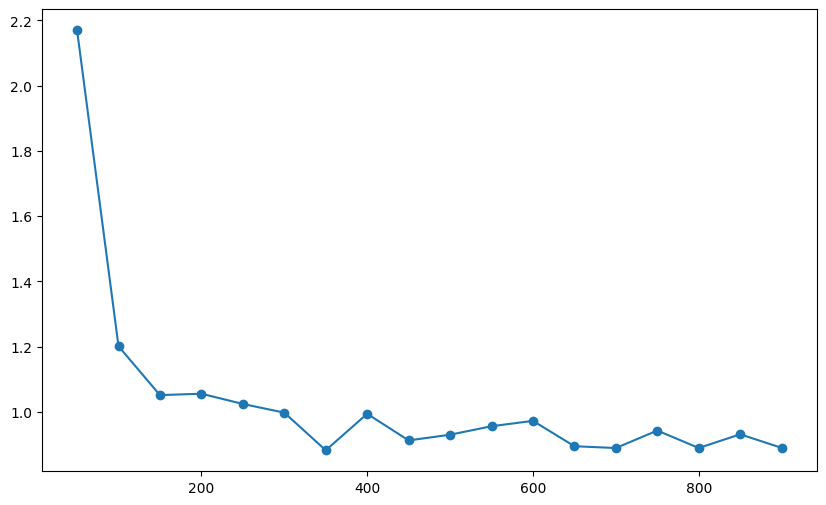

In [7]:
import matplotlib.pyplot as plt

# Extract training logs
logs = trainer.state.log_history

# Separate metrics
train_loss = [log["loss"] for log in logs if "loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]
steps = [log["step"] for log in logs if "loss" in log]

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label="Training Loss", marker="o")
plt.plot(steps, eval_loss, label="Validation Loss", marker="x")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [8]:
results = trainer.evaluate(tokenized_datasets["test"])
print("Evaluation Results:", results)

Evaluation Results: {'eval_loss': 1.0536201000213623, 'eval_runtime': 5.5621, 'eval_samples_per_second': 179.789, 'eval_steps_per_second': 11.327, 'epoch': 3.0}


In [9]:
model.save_pretrained("./final_optimized_model")
tokenizer.save_pretrained("./final_optimized_model")

('./final_optimized_model/tokenizer_config.json',
 './final_optimized_model/special_tokens_map.json',
 './final_optimized_model/vocab.json',
 './final_optimized_model/merges.txt',
 './final_optimized_model/added_tokens.json',
 './final_optimized_model/tokenizer.json')

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 15.6 MB/s eta 0:00:00


In [12]:
from torchmetrics.text.bleu import BLEUScore

# Evaluate using BLEU score
bleu = BLEUScore()
predictions = ["model-generated-text"]
references = [["correct-answer"]]
print("BLEU Score:", bleu(predictions, references))

BLEU Score: tensor(0.)


In [21]:
class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, d_model, num_heads, lambda_init=0.8):
        super().__init__()
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.scale = 1 / math.sqrt(self.d_head)

        # Linear projections for Q, K, and V
        self.w_q = nn.Linear(d_model, d_model * 2)  # [Q1; Q2]
        self.w_k = nn.Linear(d_model, d_model * 2)  # [K1; K2]
        self.w_v = nn.Linear(d_model, d_model)     # V

        # Learnable lambda components
        self.lambda_q1 = nn.Parameter(torch.zeros(self.d_head))
        self.lambda_k1 = nn.Parameter(torch.zeros(self.d_head))
        self.lambda_q2 = nn.Parameter(torch.zeros(self.d_head))
        self.lambda_k2 = nn.Parameter(torch.zeros(self.d_head))
        self.lambda_init = lambda_init

    def forward(self, hidden_states, layer_past=None, attention_mask=None, head_mask=None, **kwargs):
        # Compute Q1, Q2, K1, K2, V
        q1, q2 = self.w_q(hidden_states).chunk(2, dim=-1)
        k1, k2 = self.w_k(hidden_states).chunk(2, dim=-1)
        v = self.w_v(hidden_states)

        # Compute attention scores
        attn1 = torch.softmax((q1 @ k1.transpose(-2, -1)) * self.scale, dim=-1)
        attn2 = torch.softmax((q2 @ k2.transpose(-2, -1)) * self.scale, dim=-1)

        # Compute learnable lambda
        lambda_value = (
            torch.exp(self.lambda_q1 @ self.lambda_k1)
            - torch.exp(self.lambda_q2 @ self.lambda_k2)
            + self.lambda_init
        )

        # Differential attention
        diff_attn = attn1 - lambda_value * attn2
        updated_hidden_states = diff_attn @ v

        # Return a tuple with updated hidden states, `None` for past key values, and `None` for attention weights
        return (updated_hidden_states, None, None)


In [22]:
class ModifiedGPT2Attention(nn.Module):
    def __init__(self, config, use_differential_attention=False):
        super().__init__()
        self.use_differential_attention = use_differential_attention
        if use_differential_attention:
            self.attention = MultiHeadDifferentialAttention(
                d_model=config.hidden_size,
                num_heads=config.num_attention_heads
            )
        else:
            self.attention = GPT2Attention(config)

    def forward(self, hidden_states, layer_past=None, attention_mask=None, **kwargs):
        if self.use_differential_attention:
            # Call custom differential attention layer
            outputs = self.attention(hidden_states, layer_past, attention_mask, **kwargs)
            return outputs
        else:
            # Call standard GPT2Attention layer
            return self.attention(hidden_states, layer_past=layer_past, attention_mask=attention_mask, **kwargs)

In [23]:
from transformers import AutoModelForCausalLM

def modify_attention_layers(model, percentage_replaced=0.25):
    num_layers = len(model.transformer.h)
    num_replacements = int(num_layers * percentage_replaced)

    for i in range(num_replacements):
        model.transformer.h[i].attn = ModifiedGPT2Attention(
            model.config, use_differential_attention=True
        )
    return model

# Load the base model and apply the modifications
model = AutoModelForCausalLM.from_pretrained("aubmindlab/aragpt2-base")
model = modify_attention_layers(model, percentage_replaced=0.25)

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
)

# Train the modified model
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.004100,1.088280
2,0.982300,1.083184
3,0.896600,1.065002


TrainOutput(global_step=939, training_loss=1.1245747404738355, metrics={'train_runtime': 273.8603, 'train_samples_per_second': 54.772, 'train_steps_per_second': 3.429, 'total_flos': 1000264826880000.0, 'train_loss': 1.1245747404738355, 'epoch': 3.0})

In [25]:
# Evaluate the modified model
results = trainer.evaluate(tokenized_datasets["test"])
print("Modified Model Evaluation:", results)

# Compute BLEU score
bleu = BLEUScore()
predictions = ["model-generated-text"]
references = [["correct-answer"]]
print("BLEU Score:", bleu(predictions, references))


Modified Model Evaluation: {'eval_loss': 1.0573716163635254, 'eval_runtime': 5.1842, 'eval_samples_per_second': 192.892, 'eval_steps_per_second': 12.152, 'epoch': 3.0}
BLEU Score: tensor(0.)
